# Tutorial 03: Model Setup and Parameters

## Overview

This tutorial covers the `GR_disc` model class: what its parameters mean, how the
model is evaluated, and — the part that trips up most new users — the difference
between the **physical** parameters of the disc and the **sampled** parameters
that the fitter actually works with.

## Learning Objectives

By the end of this tutorial, you will:

- Understand the `GR_disc` model structure
- Know the seven disc parameters and the early-time parameters, and what they mean
- Understand which variable is *sampled* for each physical quantity, and why it matters
- Be able to build a valid parameter vector with `pack_parameters()`
- Know how to evaluate a model (`model_UV`, `model_X`, `get_Temperature`)

## Prerequisites

- **Tutorial 01: Data Loading Basics**
- Basic familiarity with accretion disc physics is helpful but not required

## The GR_disc model

`GR_disc` implements a time-dependent general relativistic accretion disc. It solves
the disc evolution equations to get the temperature profile as a function of radius
and time, then integrates that profile — including Doppler shifting, gravitational
energy shifting and lensing — to produce multi-wavelength light curves.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


## Creating a model

```python
model = fitted.models.GR_disc(
    data=data_set,              # Data_Set object (optional; empty set if None)
    colour_correction=True,     # Done+2012 colour correction
    rest_frame=True,            # data are in the rest frame
    decay=True,                 # include an early-time decaying component
    decay_type='pl',            # 'pl' (power law) or 'exp' (exponential)
    rise=False,                 # include an early-time rising component
    rise_type='gauss',
    # ... plus the accuracy/performance options covered in Tutorial 09
)
```

The early-time component is a simple blackbody standing in for whatever powers the
optical flare before the disc dominates. It is not part of the disc solution; it is
there so that the disc parameters are not distorted by trying to fit early light the
disc cannot produce.

In [2]:
data = fitted.data.Data_Set()

model = fitted.models.GR_disc(
    data=data,
    decay=True,
    decay_type='pl',
    rise=False,
)

print("Key parameters:  ", model.default_key_pars)
print("Early parameters:", model.default_early_pars)
print("Total:            %d" % (len(model.default_key_pars)
                                + len(model.default_early_pars)))

Key parameters:   ['log_mh', 'a_bh', 'log_m_disc', 'log_r0', 'log_tvi', 't0', 'cos_incl']
Early parameters: ['log_L', 't_fb', 'p', 'log_T']
Total:            11


## The seven disc parameters

These are the physical quantities. Every one of them enters the disc equations
directly.

| Quantity  | Description                                        | Units             | Typical |
|-----------|----------------------------------------------------|-------------------|---------|
| `log_mh`  | log₁₀ black hole mass                              | log₁₀(M☉)         | 7.0     |
| `a_bh`    | black hole spin                                    | dimensionless     | 0.01    |
| `m_disc`  | disc mass                                          | M☉                | 0.05    |
| `r0`      | radius of the initial disc density spike           | gravitational radii | 30    |
| `tvi`     | viscous (evolutionary) timescale                   | days              | 15      |
| `t0`      | time before the first observation that the disc formed | days          | -2      |
| `incl`    | disc–observer inclination                          | degrees           | 70      |

Notes:

- `a_bh` is the dimensionless spin, −0.999 < `a_bh` < 0.999. Positive is prograde,
  negative retrograde. It sets the ISCO radius and therefore how hot the inner disc gets.
- `r0` is in gravitational radii, r_g = GM/c². It is where the disc material starts,
  before it spreads viscously.
- `incl` is capped at 89°; exactly edge-on is numerically singular.

### Early-time parameters

Which of these exist depends on `decay`, `decay_type` and `rise`.

| Quantity  | Description                        | Units        | Present when |
|-----------|------------------------------------|--------------|--------------|
| `log_L`   | log₁₀ peak luminosity of the component | log₁₀(erg/s) at 6×10¹⁴ Hz | `decay=True` |
| `t_fb`    | fall-back timescale                | days         | `decay_type='pl'` |
| `p`       | power-law decay index              | dimensionless | `decay_type='pl'` |
| `t_decay` | e-folding timescale                | days         | `decay_type='exp'` |
| `log_T`   | log₁₀ temperature of the component | log₁₀(K)     | `decay=True` |
| `t_peak`  | time of peak                       | days         | `rise=True` |
| `sigma`   | Gaussian rise timescale            | days         | `rise=True` |

- Power-law decay: `L(t) ∝ ((t + t_fb)/t_fb)^(−p)`, zero before `t = −t_fb`.
- Exponential decay: `L(t) ∝ exp(−t/t_decay)`.
- Gaussian rise: `L(t) ∝ exp(−(t − t_peak)²/2σ²)`.

## Physical parameters vs sampled parameters

**This is the single most important thing in this tutorial.**

The seven quantities above are what the physics uses. They are not necessarily what
the *sampler* uses. By default `GR_disc` samples the disc mass, initial radius and
viscous time in log₁₀, and the inclination as a cosine:

| Physical | Sampled by default | Why |
|----------|--------------------|-----|
| `m_disc` | `log_m_disc` | spans orders of magnitude; log is the scale-free choice |
| `r0`     | `log_r0`     | same |
| `tvi`    | `log_tvi`    | same |
| `incl`   | `cos_incl`   | uniform in cos(i) is the isotropic viewing-angle prior |

Two consequences:

1. A parameter vector you hand to `log_likelihood`, `best_fit` or `run_chain` must be
   in the **sampled** space. Passing `incl = 70` where `cos_incl` is expected is not
   an approximation — 70 is outside the `cos_incl` bounds, the prior returns `-inf`,
   and the chain will never start.
2. This is a change of variable, so it changes the **prior**, not the likelihood.
   Uniform in `log_m_disc` is a Jeffreys prior on `m_disc`. That is usually what you
   want for a scale parameter, but it is a choice, and you should know you are making it.

You can turn any of them off — `fit_log_m_disc=False`, `fit_cos_incl=False`, and so on
(Tutorial 09) — but then you inherit a uniform prior on the linear quantity instead.

`what_pars()` always tells you what *this* model instance expects, in order.

In [3]:
model.what_pars()


You are using the GR_disc model class.
This model samples 7 key parameters and 4 early-time parameters,
in this order:

  [ 0] log_mh      = the logarithm of the black hole mass in units of solar masses.
  [ 1] a_bh        = the black hole spin (dimensionless -0.999 < a_bh < 0.999).
  [ 2] log_m_disc  = log10 of the disc mass in solar masses.
  [ 3] log_r0      = log10 of the initial disc radius (gravitational radii).
  [ 4] log_tvi     = log10 of the viscous timescale in days.
  [ 5] t0          = time before first observation that the disc formed (days).
  [ 6] cos_incl    = the cosine of the disc-observer inclination angle.
  [ 7] log_L       = log10 of the peak luminosity of the non-disc component (erg/s at 6e14 Hz).
  [ 8] t_fb        = the fall-back timescale of the non-disc component (days).
  [ 9] p           = the power-law decay index of the non-disc component.
  [10] log_T       = log10 of the temperature of the non-disc component (kelvin).

Note: log_m_disc, log_r0, log_tv

### Building a parameter vector: `pack_parameters()`

Rather than remembering which slot is in which space, give `pack_parameters()` the
physical values and let it build the vector. It is correct whatever the flags are set
to, which also means your notebook does not silently break when a default changes.

In [4]:
pars = model.pack_parameters(
    log_mh=7.0, a_bh=0.01, m_disc=0.05, r0=30.0, tvi=15.0, t0=-2.0, incl=70.0,
    log_L=43.3, t_fb=67.0, p=5/3, log_T=4.8,
)

names = model.default_key_pars + model.default_early_pars
for name, value in zip(names, pars):
    print("  %-11s %10.4f" % (name, value))

  log_mh          7.0000
  a_bh            0.0100
  log_m_disc     -1.3010
  log_r0          1.4771
  log_tvi         1.1761
  t0             -2.0000
  cos_incl        0.3420
  log_L          43.3000
  t_fb           67.0000
  p               1.6667
  log_T           4.8000


`convert_parameters()` goes the other way — sampled back to physical. Use it when you
have a chain and want to quote a disc mass in solar masses rather than a log.

In [5]:
physical = model.convert_parameters(pars, names)

print("%-12s %12s %12s" % ("parameter", "sampled", "physical"))
for name, s, p in zip(names, pars, physical):
    print("%-12s %12.4f %12.4f" % (name, s, p))

# The two are exact inverses, so the round trip is lossless.
back = model.pack_parameters(
    log_mh=physical[0], a_bh=physical[1], m_disc=physical[2], r0=physical[3],
    tvi=physical[4], t0=physical[5], incl=physical[6],
    log_L=physical[7], t_fb=physical[8], p=physical[9], log_T=physical[10],
)
print("\nmax round-trip error: %.2e" % np.max(np.abs(back - pars)))

parameter         sampled     physical
log_mh             7.0000       7.0000
a_bh               0.0100       0.0100
log_m_disc        -1.3010       0.0500
log_r0             1.4771      30.0000
log_tvi            1.1761      15.0000
t0                -2.0000      -2.0000
cos_incl           0.3420      70.0000
log_L             43.3000      43.3000
t_fb              67.0000      67.0000
p                  1.6667       1.6667
log_T              4.8000       4.8000

max round-trip error: 0.00e+00


### Parameter bounds

`default_bounds` is keyed by the *sampled* names, and the bounds are transformed
along with the parameter. The default prior is uniform inside these and zero outside.

In [6]:
print("Key parameter bounds (sampled space):")
for name in model.default_key_pars:
    print("  %-11s %s" % (name, model.default_bounds[name]))

print("\nEarly parameter bounds:")
for name in model.default_early_pars:
    print("  %-11s %s" % (name, model.default_bounds[name]))

Key parameter bounds (sampled space):
  log_mh      (0, 10)
  a_bh        (-0.999, 0.999)
  log_m_disc  (np.float64(-3.0), inf)
  log_r0      (np.float64(0.0), np.float64(4.0))
  log_tvi     (np.float64(0.0), np.float64(3.0))
  t0          (-100, 365.25)
  cos_incl    (np.float64(0.017452406437283376), np.float64(1.0))

Early parameter bounds:
  log_L       (0, inf)
  t_fb        (0.1, 1000)
  p           (0, 10)
  log_T       (4, 5)


## Evaluating the model

The evaluation methods are a deliberate exception: `model_UV`, `model_X` and
`get_Temperature` always take **physical** values, in the fixed order
`(log_mh, a_bh, m_disc, r0, tvi, t0, incl)`, regardless of how the model samples.
They are direct calls to the physics, not to the fitter.

```python
lum = model.model_UV(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, v=frequency)
lum = model.model_X(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, El=0.3, Eh=10.0)
r, T = model.get_Temperature(times, log_mh, a_bh, m_disc, r0, tvi, t0, N=1000)
```

`model_UV` returns νL_ν in erg/s at the requested rest-frame frequency; `model_X`
returns the luminosity integrated over the rest-frame band `[El, Eh]` in keV;
`get_Temperature` returns the radial grid in gravitational radii and the effective
temperature in kelvin, with shape `(len(times), len(r))`.

In [7]:
log_mh, a_bh, m_disc, r0, tvi, t0, incl = 7.0, 0.01, 0.05, 30.0, 15.0, -2.0, 70.0

# Log-spaced in time, and starting AFTER the disc forms.
#
# `t0 = -2` means the disc forms 2 days into the time axis, so the model is
# undefined at t <= 2: asking for it there returns L = 0 with a divide warning
# from the intermediate 1/(viscous time), which is correct but not interesting.
#
# Log spacing puts the resolution where the light curve actually changes. Early
# evolution happens on the viscous time (15 days here); late evolution is a slow
# power law, and does not need 200 evenly spaced samples to describe it.
times = np.geomspace(2.5, 400, 400)       # days, rest frame

lum_uv = model.model_UV(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, v=6.0e14)
lum_x = model.model_X(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, El=0.3, Eh=10.0)

# A handful of epochs is enough for the temperature profile, spread over the
# evolution so the spreading is visible.
epochs = np.geomspace(3.0, 400, 7)
r, T = model.get_Temperature(epochs, log_mh, a_bh, m_disc, r0, tvi, t0, N=2000)

print("UV light curve:      %d points, peak %.2e erg/s" % (len(lum_uv), lum_uv.max()))
print("X-ray light curve:   %d points, peak %.2e erg/s" % (len(lum_x), lum_x.max()))
print("Temperature profile: %s (epochs x radii)" % (T.shape,))
print("  radii  %.1f to %.0f r_g" % (r.min(), r.max()))
print("  T      up to %.2e K" % T.max())

UV light curve:      400 points, peak 8.14e+41 erg/s
X-ray light curve:   400 points, peak 1.84e+44 erg/s
Temperature profile: (7, 2000) (epochs x radii)
  radii  6.0 to 4020 r_g
  T      up to 2.68e+05 K


The two bands behave completely differently, and the reason is the disc temperature.

A blackbody at temperature *T* peaks near *hν ≈ kT*. Turn each band into the
temperature it is asking about:

| Band | Photon energy | Equivalent temperature |
|------|---------------|------------------------|
| optical, 6 × 10¹⁴ Hz | 2.5 eV | 2.9 × 10⁴ K |
| X-ray, 0.3 keV | 300 eV | 3.5 × 10⁶ K |
| X-ray, 10 keV | 10 keV | 1.2 × 10⁸ K |

The disc here never gets hotter than about 3 × 10⁵ K. So the optical sits *below* the
disc temperature — on the Rayleigh–Jeans side, where νL_ν ∝ T and the response is gentle
and nearly linear. The X-ray sits one to three orders of magnitude *above* it, far out on
the Wien tail, where the dependence is exponential in hν/kT.

The dashed lines in the third panel below mark those two temperatures, and the cell after
it quantifies what the difference costs.

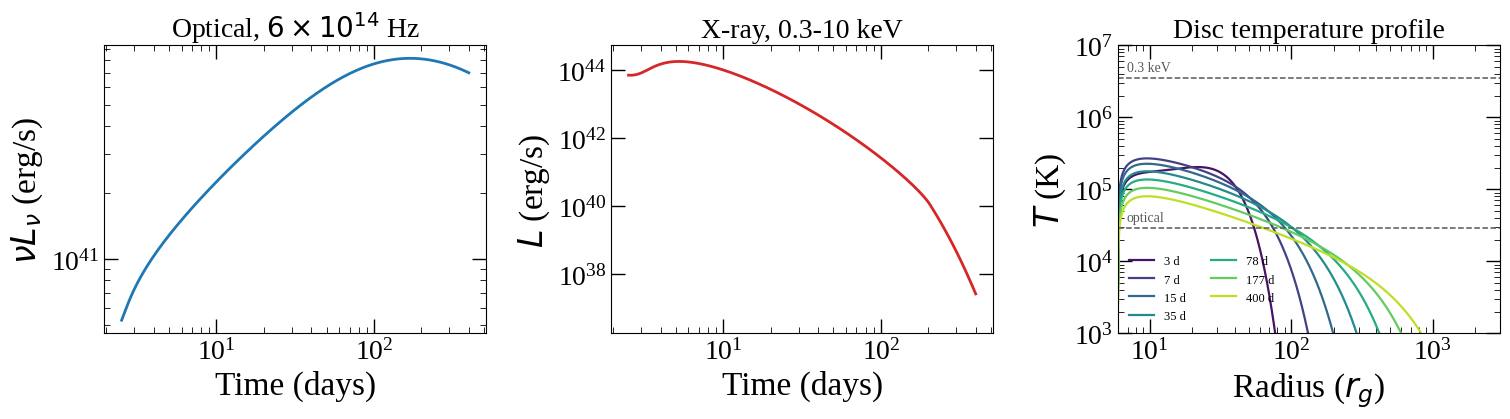

In [8]:
from matplotlib import cm

# Photon energy expressed as a temperature, hv = kT.
h_erg_s, k_B = 6.62607015e-27, 1.380649e-16
T_optical = h_erg_s * 6.0e14 / k_B                 # ~2.9e4 K
T_xray_lo = 0.3e3 / 8.617333262e-5                 # 0.3 keV -> ~3.5e6 K

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 4.6))

ax1.plot(times, lum_uv, 'C0-', lw=2)
ax1.set(xlabel='Time (days)', ylabel=r'$\nu L_\nu$ (erg/s)',
        xscale='log', yscale='log',
        title=r'Optical, $6\times10^{14}$ Hz')

ax2.plot(times, lum_x, 'C3-', lw=2)
ax2.set(xlabel='Time (days)', ylabel=r'$L$ (erg/s)',
        xscale='log', yscale='log',
        title='X-ray, 0.3-10 keV')
# The X-ray spans many decades; keep the axis to the part that is meaningful.
ax2.set_ylim(max(lum_x.max() * 1e-8, 1e35), lum_x.max() * 3)

colours = cm.viridis(np.linspace(0.05, 0.9, len(epochs)))
for Ti, tt, c in zip(T, epochs, colours):
    ax3.plot(r, Ti, lw=1.6, color=c, label='%.0f d' % tt)

for T_line, label in ((T_optical, 'optical'), (T_xray_lo, '0.3 keV')):
    ax3.axhline(T_line, color='0.35', ls='--', lw=1.1)
    ax3.text(r.min() * 1.15, T_line * 1.25, label, fontsize=10, color='0.35')

# Cut the y-axis at a physically meaningful floor. The model's temperature falls
# to zero outside the disc, so on a log axis autoscaling reaches absurd values
# (1e-12 K and below) and squashes the four decades that matter into nothing.
ax3.set(xlabel=r'Radius ($r_g$)', ylabel=r'$T$ (K)',
        xscale='log', yscale='log',
        xlim=(r.min(), 3e3), ylim=(1e3, 1e7),
        title='Disc temperature profile')
# Lower left is the empty corner here; 'best' puts it on top of the 0.3 keV line.
ax3.legend(frameon=False, fontsize=9, ncol=2, loc='lower left')

fig.tight_layout()
plt.show()

In [9]:
# How much does each observable move, over the same evolution?
T_in_hot, T_in_late = T[1].max(), T[-1].max()
print("inner disc temperature  %.2e -> %.2e K      factor %5.1f"
      % (T_in_hot, T_in_late, T_in_hot / T_in_late))
print("optical nu L_nu         %.2e -> %.2e erg/s  factor %5.1f  (rises, then flattens)"
      % (lum_uv[0], lum_uv[-1], lum_uv.max() / lum_uv.min()))
print("X-ray L                 %.2e -> %.2e erg/s  factor %5.1e  (%.1f decades)"
      % (lum_x.max(), lum_x[-1], lum_x.max() / lum_x[-1],
         np.log10(lum_x.max() / lum_x[-1])))

inner disc temperature  2.68e+05 -> 8.00e+04 K      factor   3.4
optical nu L_nu         5.28e+40 -> 6.99e+41 erg/s  factor  15.4  (rises, then flattens)
X-ray L                 1.84e+44 -> 2.66e+37 erg/s  factor 6.9e+06  (6.8 decades)


That is the point of this tutorial in three lines. **The inner disc cools by a factor of
about three. The optical moves by a factor of about fifteen. The X-ray falls by a factor of
several million.** Same disc, same temperature evolution, three completely different
responses — because of where each band sits relative to kT.

Reading the temperature panel with that in mind:

Material starts concentrated near `r0 = 30` r_g and spreads viscously, inward and outward.
The inner edge fills in and heats up over the first few viscous times, so the profile
*rises* at small radii early on; then mass drains through the ISCO and the whole profile
cools. Later curves extend to larger radii and sit lower.

The optical line at 2.9 × 10⁴ K is crossed by the profile at every epoch, and the radius
at which it is crossed moves *outward* as the disc spreads. So the optical emitting area
grows even while the inner disc cools, and νL_ν ∝ ∫T dA actually **rises** through most of
this window — it peaks around 170 days here, long after the X-ray has peaked at 5 days.
A rising optical light curve and a plummeting X-ray light curve are not in conflict.

The 0.3 keV line at 3.5 × 10⁶ K sits *above the entire profile at every epoch*. No part of
this disc is hot enough to emit 0.3 keV photons thermally, so the X-rays come entirely
from the exponential Wien tail of the hottest inner annuli — which is why a factor of
three in temperature becomes a factor of a million in flux.

It is also why the X-ray upper limits in tutorials 04 and 05 do real work: a slightly
hotter inner disc changes the X-ray prediction enormously, so a non-detection is a sharp
statement about the inner disc.

## Summary

- `GR_disc` has seven disc parameters plus a handful of early-time parameters.
- The **sampled** vector is not the same as the **physical** vector. Build it with
  `pack_parameters()` and read it back with `convert_parameters()`.
- `what_pars()` reports what the instance in front of you actually expects.
- `model_UV`, `model_X` and `get_Temperature` are the exception — they always take
  physical values.

## Next steps

- **Tutorial 04: Basic Fitting Workflow** — fit this model to data
- **Tutorial 09: Advanced Model Options** — the accuracy and performance flags

## Further reading

- **Paper Section 2**: the physical model (arXiv:2408.15048)
- `fitted/examples/fitting_models.py`